# 雙動能交易策略 - 逐標的暴力演算最佳化
這是一個自動生成的筆記本，包含了完整的資料處理、逐標的參數最佳化及投資組合回測邏輯。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import itertools
from itertools import combinations
import xlsxwriter
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. 參數集中管理區
# =============================================================================
DATA_FILE = '資料2.xlsx'
INITIAL_CAPITAL = 10000000
NUM_SLOTS = 2
LOOKBACK_RANGE = range(2, 53)
OUTPUT_EXCEL = 'strategy_results_asset.xlsx'
OUTPUT_MD = 'reproduce_report_asset.md'


## 2. 資料讀取與清理

In [2]:
def load_data(filepath):
    df = pd.read_excel(filepath)
    df['時間'] = pd.to_datetime(df['時間'])
    df.set_index('時間', inplace=True)
    df = df.sort_index().ffill()
    return df

df_prices = load_data(DATA_FILE)
print(f"資料讀取完成，共 {len(df_prices)} 周，{len(df_prices.columns)} 檔商品。")


資料讀取完成，共 448 周，16 檔商品。


## 3. 績效評估指標

In [3]:
def calculate_metrics(eq):
    years = len(eq) / 52.18
    total_return = eq.iloc[-1] / eq.iloc[0]
    cagr = total_return**(1/years) - 1
    rolling_max = eq.cummax()
    drawdowns = (eq - rolling_max) / rolling_max
    max_dd = drawdowns.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    win_rate = (eq.pct_change() > 0).mean()
    return {'CAGR': cagr, 'MaxDD': max_dd, 'Calmar': calmar, 'WinRate': win_rate}


## 4. 逐標的最佳化 (Per-Asset Optimization)
針對每檔商品搜尋其最佳的動能週期組合。

In [4]:
def optimize_assets(df):
    results = {}
    n_range = list(LOOKBACK_RANGE)
    for asset in df.columns:
        prices = df[asset]
        returns = (prices.shift(-1) / prices - 1).fillna(0).values
        rocs = {n: (prices / prices.shift(n) - 1).values for n in n_range}
        
        best_a = {'calmar': -1, 'params': [12]}
        # 測試單、雙週期組合 (範例使用單、雙以加速)
        candidates = [[n] for n in n_range] + [list(p) for p in combinations(n_range[::2], 2)]
        
        for p in candidates:
            score = np.mean([rocs[n] for n in p], axis=0)
            signal = (score > 0).astype(float)
            equity = np.exp(np.cumsum(np.log1p(signal * returns)))
            # Calculate simple calmar for optimization
            final_ret = equity[-1]
            mdd = (equity / np.maximum.accumulate(equity)).min() - 1
            calmar = (final_ret - 1) / abs(mdd) if mdd != 0 else 0
            
            if calmar > best_a['calmar']:
                best_a = {'calmar': calmar, 'params': p}
        results[asset] = best_a['params']
    return results

best_params = optimize_assets(df_prices)
print("各商品最佳參數優化完成。")


各商品最佳參數優化完成。


## 5. 投資組合回測 (Portfolio Backtest)
依照「保留原股數」與「2格位資金獨立」規則。

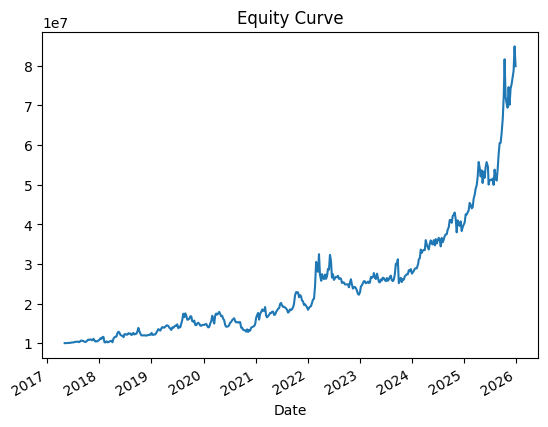

策略最終績效: CAGR=27.39%, MaxDD=-31.53%, Calmar=0.87


In [5]:
def run_portfolio_backtest(price_df, asset_params):
    dates = price_df.index
    slots = [{'asset': None, 'shares': 0, 'cash': INITIAL_CAPITAL / NUM_SLOTS} for _ in range(NUM_SLOTS)]
    history = []
    
    for i, date in enumerate(dates):
        # 計算當前動能分數
        scores = {}
        for asset in price_df.columns:
            p = asset_params[asset]
            idx = i
            vals = []
            for n in p:
                if idx >= n:
                    past = price_df.iloc[idx-n][asset]
                    vals.append(price_df.iloc[idx][asset] / past - 1 if past > 0 else -1)
                else: vals.append(-1)
            scores[asset] = np.mean(vals)
            
        targets = [a for a, s in sorted(scores.items(), key=lambda x: x[1], reverse=True) if s > 0][:NUM_SLOTS]
        
        # 賣出或保留
        for j in range(NUM_SLOTS):
            curr = slots[j]['asset']
            if curr and curr not in targets:
                slots[j]['cash'] += slots[j]['shares'] * price_df.loc[date, curr]
                slots[j]['asset'] = None; slots[j]['shares'] = 0
        
        # 買進
        held = [s['asset'] for s in slots if s['asset']]
        needed = [t for t in targets if t not in held]
        for j in range(NUM_SLOTS):
            if slots[j]['asset'] is None and needed:
                new_a = needed.pop(0)
                price = price_df.loc[date, new_a]
                if not np.isnan(price) and price > 0:
                    slots[j]['shares'] = slots[j]['cash'] / price
                    slots[j]['cash'] = 0; slots[j]['asset'] = new_a
        
        total_val = sum(s['cash'] + s['shares'] * price_df.loc[date, s['asset']] if s['asset'] else s['cash'] for s in slots)
        history.append({'Date': date, 'TotalValue': total_val, 'Holdings': [s['asset'] for s in slots]})
        
    return pd.DataFrame(history)

results_df = run_portfolio_backtest(df_prices, best_params)
results_df.set_index('Date')['TotalValue'].plot(title='Equity Curve')
plt.show()

metrics = calculate_metrics(results_df['TotalValue'])
print(f"策略最終績效: CAGR={metrics['CAGR']:.2%}, MaxDD={metrics['MaxDD']:.2%}, Calmar={metrics['Calmar']:.2f}")
